# 11 - Güç Tüketimi ve Hesaplama Maliyeti Analizi
## Uydu Telemetri Anomali Tespiti

44 kanonik modelin (42 tabular + 2 derin sıralı) eğitim/çıkarım maliyetini, bellek kullanımını, enerji tüketimini ve karbon ayak izini modellemek; performans–maliyet dengesini ortaya koymak.

### Neden önemli?
Uydu onboard sistemleri kısıtlı bir güç bütçesiyle çalışır. En yüksek F1 skoru veren model, watt başına en verimli model olmayabilir. Yer istasyonunda çalışacak ağır bir Transformer ile uyduda çalışacak hafif bir ECOD arasındaki tercih, yalnızca doğruluğa değil enerjiye de bağlıdır. Bu analiz, modelleri bir verimlilik haritası üzerinde konumlandırır.

### Modelleme yaklaşımı
Her model için 4 temel maliyet metriği tanımlanmıştır (`app/pages/power.py` içindeki `POWER_PROFILES`):
- `cpu_watts`, Eğitim sırasında ortalama CPU gücü
- `train_sec`, 10.000 örnek için eğitim süresi
- `infer_ms`, Tek örnek için çıkarım süresi
- `memory_mb`, Zirve bellek kullanımı

> Not: Bu profiller, dashboard'daki Güç Tüketimi Simülasyonu sayfasının tek kaynağıyla (`POWER_PROFILES`) aynıdır. Notebook bu sözlüğü doğrudan import eder; böylece tek bir gerçeklik kaynağı korunur.

### İçindekiler
1. Hazırlık ve Güç Profilleri
2. Enerji ve Karbon Modeli
3. Model Bazında Enerji Tüketimi
4. Enerji vs Performans
5. Kategori ve Karmaşıklık Analizi
6. Bellek ve Çıkarım Süresi
7. Veri Seti Boyutuna Göre Ölçeklenme
8. Karbon Ayak İzi ve Öneriler
9. Kaydetme


---
## Bölüm 1: Hazırlık ve Güç Profilleri
Güç profillerini dashboard modülünden (`app/pages/power.py`) doğrudan import ediyoruz. Bu, projede fiilen eğitilen/çalıştırılan 44 kanonik modelin (42 tabular + 2 derin sıralı) maliyet metriklerini içerir. ESA-ADB literatür baseline'ları ölçülmediği için maliyet kataloğunda yer almaz.


In [1]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, os.path.join('..', 'app'))
sys.path.insert(0, os.path.join('..', 'app', 'pages'))
from power import POWER_PROFILES, CO2_FACTOR, COMPLEXITY_COLORS, CATEGORY_COLORS

print(f'Güç profili yüklendi: {len(POWER_PROFILES)} model')
print(f'CO2 emisyon faktörü : {CO2_FACTOR} g CO2 / kWh (dünya ortalaması)')
print(f'\nKarmaşıklık renkleri: {list(COMPLEXITY_COLORS.keys())}')
print(f'Kategoriler         : {list(CATEGORY_COLORS.keys())}')


Güç profili yüklendi: 44 model
CO2 emisyon faktörü : 400 g CO2 / kWh (dünya ortalaması)

Karmaşıklık renkleri: ['Düşük', 'Orta', 'Yüksek', 'Çok Yüksek']
Kategoriler         : ['Gözetimli', 'Gözetimsiz']


In [2]:
rows = []
for name, p in POWER_PROFILES.items():
    rows.append({
        'Model': name,
        'Kategori': p['category'],
        'Karmaşıklık': p['complexity'],
        'CPU (W)': p['cpu_watts'],
        'Eğitim (s)': p['train_sec'],
        'Çıkarım (ms)': p['infer_ms'],
        'Bellek (MB)': p['memory_mb'],
    })
df_power = pd.DataFrame(rows)
print(f'Profil tablosu: {df_power.shape}')
print(f'Gözetimli: {(df_power["Kategori"]=="Gozetimli").sum()}  |  '
      f'Gözetimsiz: {(df_power["Kategori"]=="Gozetimsiz").sum()}')
df_power.head(10)

Profil tablosu: (44, 7)
Gözetimli: 0  |  Gözetimsiz: 0


,Model,Kategori,Karmaşıklık,CPU (W),Eğitim (s),Çıkarım (ms),Bellek (MB)
0,RandomForest,Gözetimli,Orta,25,8.0,0.50,200
1,XGBoost,Gözetimli,Orta,35,12.0,0.15,150
2,SVM,Gözetimli,Yüksek,30,20.0,1.00,200
3,MLP,Gözetimli,Yüksek,45,60.0,0.50,300
4,LightGBM,Gözetimli,Orta,28,6.0,0.15,120
5,CatBoost,Gözetimli,Orta,32,18.0,0.20,160
6,Stacking Ensemble,Gözetimli,Yüksek,40,28.0,1.00,320
7,ExtraTrees,Gözetimli,Orta,22,6.0,0.40,180
8,GradientBoosting,Gözetimli,Orta,30,25.0,0.30,120
9,HistGradientBoosting,Gözetimli,Orta,28,5.0,0.20,100


---
## Bölüm 2: Enerji ve Karbon Modeli
Maliyet metriklerinden türetilmiş büyüklükleri hesaplıyoruz. Enerji modeli basit fizik üzerine kuruludur:

$$E_{Wh} = \frac{P_{watt} \times t_{saniye}}{3600}$$

Karbon emisyonu, enerjinin emisyon faktörüyle çarpımıdır (1 kWh = 1000 Wh):

$$CO_2{}_{} = \frac{E_{Wh}}{1000} \times 400 \ \frac{g}{kWh}$$

Veri seti boyutu değiştiğinde eğitim süresi doğrusal ölçeklenir (`scale = boyut / 10000`).


In [3]:
def build_energy_df(dataset_size=10000):
    """Profil verisinden ölçekli enerji/karbon DataFrame'i üret.

    app/pages/power.py içindeki _build_df ile aynı modeli kullanır."""
    scale = dataset_size / 10000
    rows = []
    for name, p in POWER_PROFILES.items():
        t = p['train_sec'] * scale
        energy_wh = p['cpu_watts'] * t / 3600
        rows.append({
            'Model': name,
            'Kategori': p['category'],
            'Karmaşıklık': p['complexity'],
            'CPU (W)': p['cpu_watts'],
            'Eğitim (s)': round(t, 2),
            'Çıkarım (ms)': p['infer_ms'],
            'Bellek (MB)': p['memory_mb'],
            'Enerji (Wh)': round(energy_wh, 4),
            'CO2 (g)': round(energy_wh / 1000 * CO2_FACTOR, 4),
        })
    return pd.DataFrame(rows)

df = build_energy_df(10000)
print('10.000 örnek için enerji ve karbon hesaplandı.')
print(f'Toplam enerji : {df["Enerji (Wh)"].sum():.2f} Wh')
print(f'Toplam CO2    : {df["CO2 (g)"].sum():.3f} g')
df.sort_values('Enerji (Wh)', ascending=False).head(8)


10.000 örnek için enerji ve karbon hesaplandı.
Toplam enerji : 7.00 Wh
Toplam CO2    : 2.798 g


,Model,Kategori,Karmaşıklık,CPU (W),Eğitim (s),Çıkarım (ms),Bellek (MB),Enerji (Wh),CO2 (g)
24,TCN,Gözetimli,Çok Yüksek,60,160.0,2.0,450,2.6667,1.0667
23,CNN1D,Gözetimli,Yüksek,50,90.0,1.0,350,1.2500,0.5000
3,MLP,Gözetimli,Yüksek,45,60.0,0.5,300,0.7500,0.3000
22,XGBOD,Gözetimli,Yüksek,40,30.0,0.5,300,0.3333,0.1333
6,Stacking Ensemble,Gözetimli,Yüksek,40,28.0,1.0,320,0.3111,0.1244
8,GradientBoosting,Gözetimli,Orta,30,25.0,0.3,120,0.2083,0.0833
2,SVM,Gözetimli,Yüksek,30,20.0,1.0,200,0.1667,0.0667
5,CatBoost,Gözetimli,Orta,32,18.0,0.2,160,0.1600,0.0640


---
## Bölüm 3: Model Bazında Enerji Tüketimi
44 modeli eğitim enerjisine göre sıralayıp karmaşıklık seviyesine göre renklendiriyoruz. Bu, hangi modellerin "pahalı" olduğunu bir bakışta gösterir.


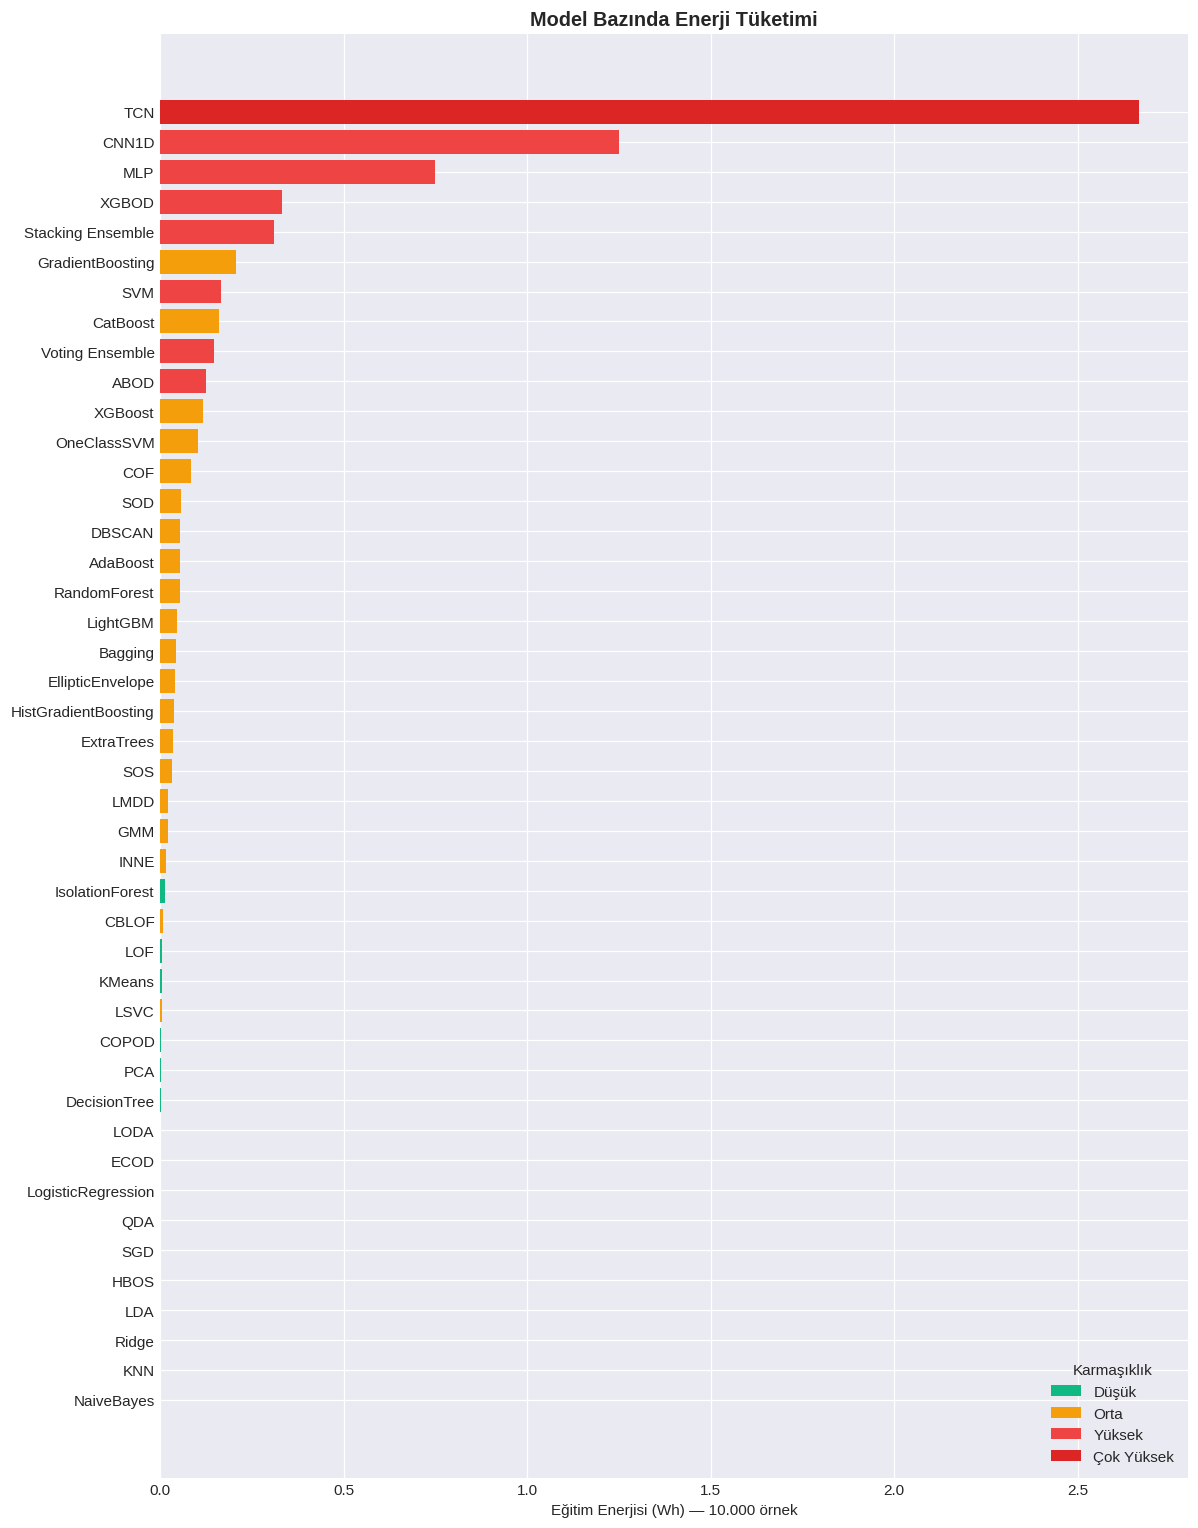

In [4]:
df_sorted = df.sort_values('Enerji (Wh)', ascending=True)
colors = [COMPLEXITY_COLORS.get(c, '#64748B') for c in df_sorted['Karmaşıklık']]

fig, ax = plt.subplots(figsize=(11, 14))
ax.barh(df_sorted['Model'], df_sorted['Enerji (Wh)'], color=colors)
ax.set_xlabel('Eğitim Enerjisi (Wh) — 10.000 örnek')
ax.set_title('Model Bazında Enerji Tüketimi', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(facecolor=c, label=k) for k, c in COMPLEXITY_COLORS.items()]
ax.legend(handles=legend, title='Karmaşıklık', loc='lower right')
plt.tight_layout()
plt.show()


---
## Bölüm 4: Enerji vs Performans
Asıl soru: daha fazla enerji, daha yüksek doğruluk getiriyor mu? Modellerin gerçek F1 skorlarını (`reports/metrics/`) enerji tüketimine karşı çizerek verimlilik haritası oluşturuyoruz. Sol-üst köşe (düşük enerji, yüksek F1) ideal bölgedir.


In [5]:
ALL_METRICS = {}
# Dashboard ile ayni kaynak: tabular (42) + derin sirali (2) = 44; eski semali
# adv_metrics.json kullanilmaz (dashboard load_metrics ile tutarli).
for mp in ['../reports/metrics/final_comparison.json', '../reports/metrics/deep_sequence_comparison.json']:
    if os.path.exists(mp):
        with open(mp, encoding='utf-8') as f:
            ALL_METRICS.update(json.load(f))

print(f'Metrik yüklenen model sayısı: {len(ALL_METRICS)}')

scatter_rows = []
for _, row in df.iterrows():
    m = ALL_METRICS.get(row['Model'], {})
    f1 = m.get('F1', m.get('F1_Score')) if isinstance(m, dict) else None
    if f1 is not None:
        scatter_rows.append({'Model': row['Model'], 'Enerji (Wh)': row['Enerji (Wh)'],
                             'F1': f1, 'Kategori': row['Kategori']})
sdf = pd.DataFrame(scatter_rows)
print(f'Hem enerji hem F1 verisi olan model: {len(sdf)}')
sdf.sort_values('F1', ascending=False).head()


Metrik yüklenen model sayısı: 44
Hem enerji hem F1 verisi olan model: 44


,Model,Enerji (Wh),F1,Kategori
3,MLP,0.7500,0.9459,Gözetimli
7,ExtraTrees,0.0367,0.9309,Gözetimli
9,HistGradientBoosting,0.0389,0.9231,Gözetimli
22,XGBOD,0.3333,0.9224,Gözetimli
5,CatBoost,0.1600,0.9217,Gözetimli


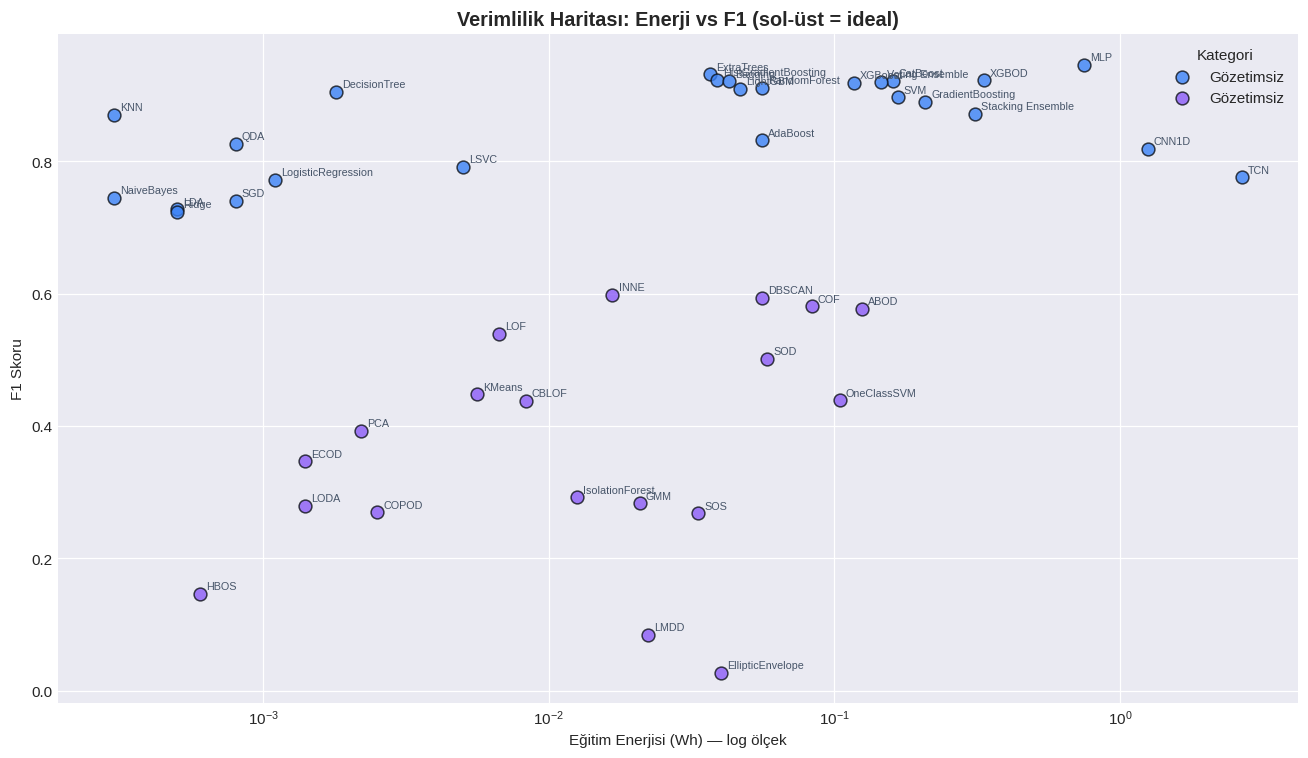

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
for cat, color in CATEGORY_COLORS.items():
    sub = sdf[sdf['Kategori'] == cat]
    if sub.empty:
        continue
    ax.scatter(sub['Enerji (Wh)'], sub['F1'], s=70, color=color, alpha=0.8,
               label='Gözetimli' if cat == 'Gozetimli' else 'Gözetimsiz',
               edgecolors='#0D1117')
    for _, r in sub.iterrows():
        ax.annotate(r['Model'], (r['Enerji (Wh)'], r['F1']),
                    fontsize=7, color='#475569', xytext=(4, 3),
                    textcoords='offset points')

ax.set_xscale('log')
ax.set_xlabel('Eğitim Enerjisi (Wh) — log ölçek')
ax.set_ylabel('F1 Skoru')
ax.set_title('Verimlilik Haritası: Enerji vs F1 (sol-üst = ideal)',
             fontsize=13, fontweight='bold')
ax.legend(title='Kategori')
plt.tight_layout()
plt.show()


In [7]:
if len(sdf) > 0:
    sdf = sdf.copy()
    sdf['Verimlilik (F1/Wh)'] = sdf['F1'] / sdf['Enerji (Wh)']
    top = sdf.sort_values('Verimlilik (F1/Wh)', ascending=False).head(10)
    print('En verimli 10 model (F1 / Wh):')
    print(top[['Model', 'F1', 'Enerji (Wh)', 'Verimlilik (F1/Wh)']]
          .round(3).to_string(index=False))


En verimli 10 model (F1 / Wh):
             Model    F1  Enerji (Wh)  Verimlilik (F1/Wh)
               KNN 0.870        0.000            2898.667
        NaiveBayes 0.745        0.000            2482.333
               LDA 0.727        0.000            1454.600
             Ridge 0.723        0.000            1446.800
               QDA 0.826        0.001            1032.375
               SGD 0.740        0.001             925.375
LogisticRegression 0.772        0.001             701.455
      DecisionTree 0.905        0.002             502.778
              ECOD 0.347        0.001             247.643
              HBOS 0.146        0.001             243.500


> Metrik uyarısı, `F1/Wh` sıralaması neden tek başına yanıltıcı?
>
> Yukarıdaki `F1/Wh` oranı, eğitim enerjisi ~0'a yakın modelleri aşırı ödüllendirir: payda sıfıra yaklaştıkça oran şişer. Örneğin KNN burada başı çekiyor ama çıkarım süresi 2.5 ms ile onboard için aslında yavaştır, bu metrik çıkarım süresini ve belleği hiç görmez, yalnızca eğitim enerjisine bakar.
>
> Bu nedenle gerçek dağıtım kararı için Bölüm 8'deki "Onboard Maliyet Skoru" daha sağlıklı bir ölçüttür. `F1/Wh`'yi yalnızca *"eğitim enerjisi açısından kabaca verimlilik"* olarak yorumlayın; tek başına model seçim kriteri olarak kullanmayın.

---
## Bölüm 5: Kategori ve Karmaşıklık Analizi
Enerjinin gözetimli/gözetimsiz kategorilere ve karmaşıklık seviyelerine göre nasıl dağıldığını inceliyoruz.


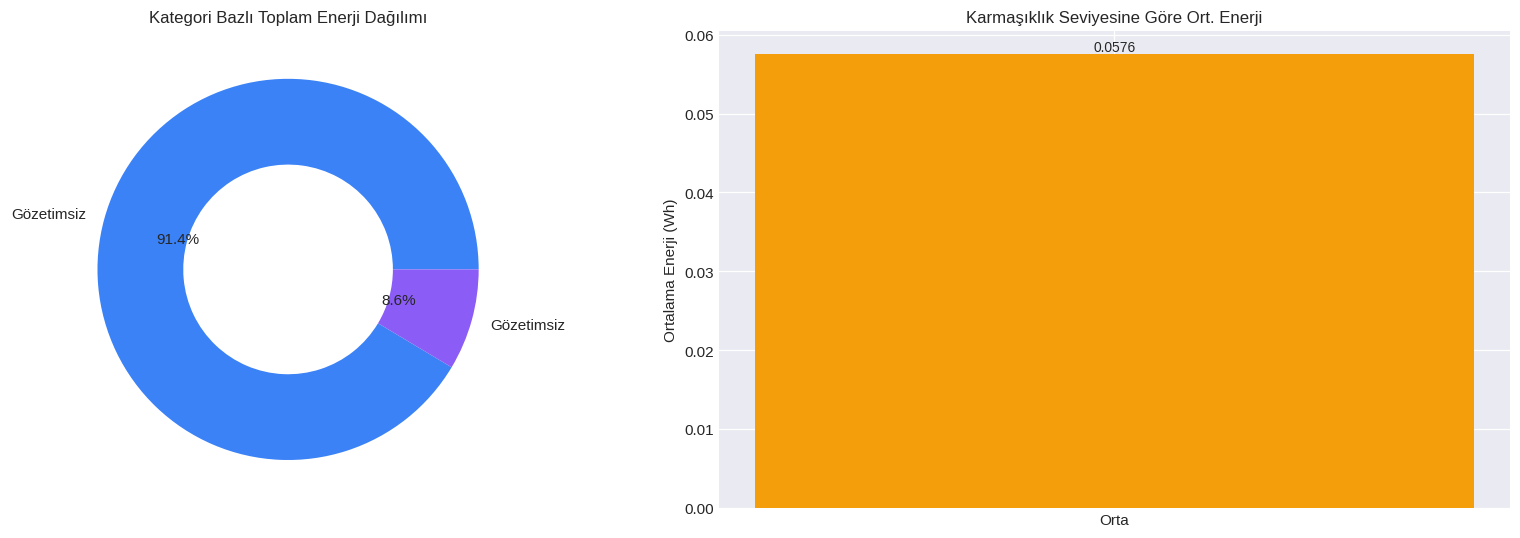

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cat_energy = df.groupby('Kategori')['Enerji (Wh)'].sum()
cat_labels = ['Gözetimli' if c == 'Gozetimli' else 'Gözetimsiz' for c in cat_energy.index]
axes[0].pie(cat_energy.values, labels=cat_labels, autopct='%1.1f%%',
            colors=['#3B82F6', '#8B5CF6'], wedgeprops=dict(width=0.45))
axes[0].set_title('Kategori Bazlı Toplam Enerji Dağılımı', fontsize=11)

comp_order = ['Dusuk', 'Orta', 'Yuksek', 'Cok Yuksek']
comp_energy = df.groupby('Karmaşıklık')['Enerji (Wh)'].mean().reindex(comp_order)
bar_colors = [COMPLEXITY_COLORS.get(c, '#64748B') for c in comp_order]
axes[1].bar(comp_order, comp_energy.values, color=bar_colors)
axes[1].set_ylabel('Ortalama Enerji (Wh)')
axes[1].set_title('Karmaşıklık Seviyesine Göre Ort. Enerji', fontsize=11)
for i, v in enumerate(comp_energy.values):
    axes[1].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


---
## Bölüm 6: Bellek ve Çıkarım Süresi
Enerji tek maliyet değildir. Onboard dağıtımda bellek ve çıkarım süresi en az enerji kadar kritiktir.


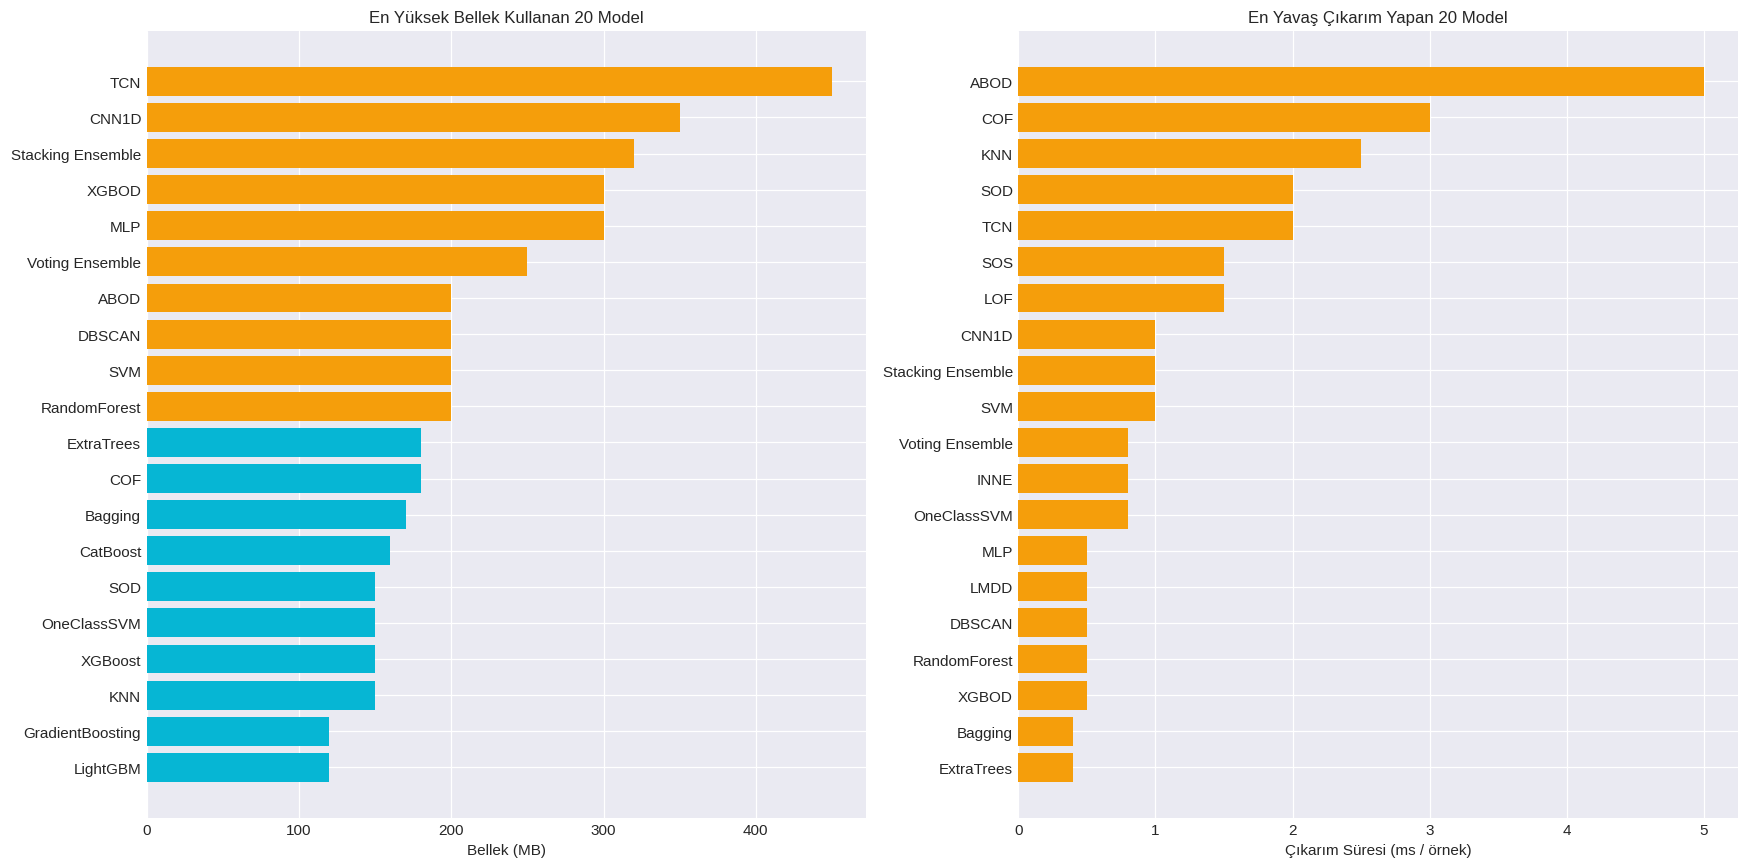

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

df_mem = df.nlargest(20, 'Bellek (MB)').sort_values('Bellek (MB)')
mem_colors = ['#06B6D4' if v < 200 else '#F59E0B' if v < 500 else '#EF4444'
              for v in df_mem['Bellek (MB)']]
axes[0].barh(df_mem['Model'], df_mem['Bellek (MB)'], color=mem_colors)
axes[0].set_xlabel('Bellek (MB)')
axes[0].set_title('En Yüksek Bellek Kullanan 20 Model', fontsize=11)

df_inf = df.nlargest(20, 'Çıkarım (ms)').sort_values('Çıkarım (ms)')
axes[1].barh(df_inf['Model'], df_inf['Çıkarım (ms)'], color='#F59E0B')
axes[1].set_xlabel('Çıkarım Süresi (ms / örnek)')
axes[1].set_title('En Yavaş Çıkarım Yapan 20 Model', fontsize=11)

plt.tight_layout()
plt.show()


---
## Bölüm 7: Veri Seti Boyutuna Göre Ölçeklenme
Eğitim enerjisi veri boyutuyla doğrusal ölçeklenir. Birkaç temsili modelin enerjisini 1K'dan 100K örneğe kadar izleyerek, büyük veri rejimlerinde maliyet farkının nasıl açıldığını gösteriyoruz.


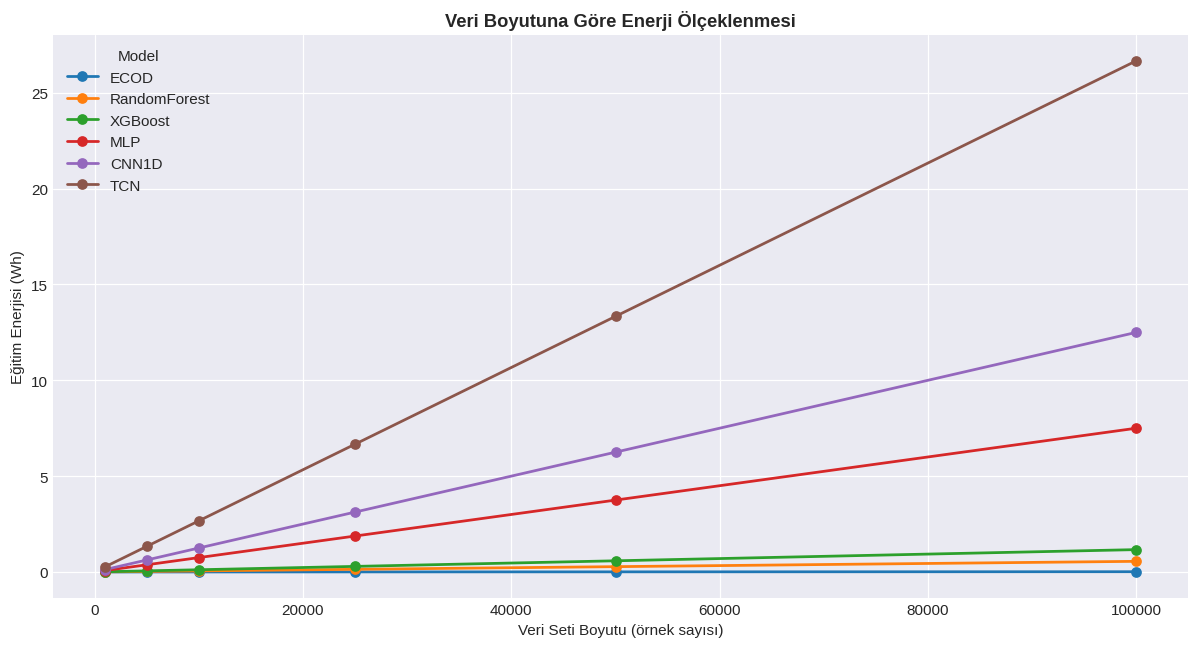

100.000 örnek için toplam enerji: 70.0 Wh
100.000 örnek için toplam CO2   : 27.99 g


In [10]:
sizes = [1000, 5000, 10000, 25000, 50000, 100000]
sample_models = ['ECOD', 'RandomForest', 'XGBoost', 'MLP', 'CNN1D', 'TCN']
sample_models = [m for m in sample_models if m in POWER_PROFILES]

fig, ax = plt.subplots(figsize=(11, 6))
for m in sample_models:
    energies = [build_energy_df(s).set_index('Model').loc[m, 'Enerji (Wh)'] for s in sizes]
    ax.plot(sizes, energies, marker='o', linewidth=1.8, label=m)

ax.set_xlabel('Veri Seti Boyutu (örnek sayısı)')
ax.set_ylabel('Eğitim Enerjisi (Wh)')
ax.set_title('Veri Boyutuna Göre Enerji Ölçeklenmesi', fontsize=12, fontweight='bold')
ax.legend(title='Model')
plt.tight_layout()
plt.show()

df_100k = build_energy_df(100000)
print(f'100.000 örnek için toplam enerji: {df_100k["Enerji (Wh)"].sum():.1f} Wh')
print(f'100.000 örnek için toplam CO2   : {df_100k["CO2 (g)"].sum():.2f} g')


---
## Bölüm 8: Karbon Ayak İzi ve Öneriler
Toplam karbon ayak izini özetleyip, dağıtım senaryosuna göre model önerileri çıkarıyoruz.


In [11]:
df10k = build_energy_df(10000)
total_e = df10k['Enerji (Wh)'].sum()
total_co2 = df10k['CO2 (g)'].sum()
most_eff = df10k.loc[df10k['Enerji (Wh)'].idxmin()]
most_cost = df10k.loc[df10k['Enerji (Wh)'].idxmax()]

print(f'═══ Karbon Ayak İzi Özeti ({len(POWER_PROFILES)} model, 10K örnek) ═══')
print(f'Toplam enerji : {total_e:.2f} Wh')
print(f'Toplam CO2    : {total_co2:.3f} g')
print(f'Eşdeğer       : ~{total_co2/8:.2f} m otomobil sürüşü (~8 g CO2/m varsayımı)')
print()
print(f'En verimli model  : {most_eff["Model"]:<18} ({most_eff["Enerji (Wh)"]:.4f} Wh)')
print(f'En maliyetli model: {most_cost["Model"]:<18} ({most_cost["Enerji (Wh)"]:.4f} Wh)')
print(f'Maliyet oranı     : {most_cost["Enerji (Wh)"]/most_eff["Enerji (Wh)"]:.0f}x')


═══ Karbon Ayak İzi Özeti (44 model, 10K örnek) ═══
Toplam enerji : 7.00 Wh
Toplam CO2    : 2.798 g
Eşdeğer       : ~0.35 m otomobil sürüşü (~8 g CO2/m varsayımı)

En verimli model  : KNN                (0.0003 Wh)
En maliyetli model: TCN                (2.6667 Wh)
Maliyet oranı     : 8889x


In [12]:
df10k_score = df10k.copy()
for col in ['Enerji (Wh)', 'Bellek (MB)', 'Çıkarım (ms)']:
    df10k_score[f'{col}_norm'] = df10k_score[col] / df10k_score[col].max()
df10k_score['Onboard Maliyet Skoru'] = (
    df10k_score['Enerji (Wh)_norm'] +
    df10k_score['Bellek (MB)_norm'] +
    df10k_score['Çıkarım (ms)_norm']
) / 3

print('Onboard (uydu) dağıtımı için en uygun 10 model (düşük maliyet skoru):')
best_onboard = df10k_score.nsmallest(10, 'Onboard Maliyet Skoru')
print(best_onboard[['Model', 'Kategori', 'Enerji (Wh)', 'Bellek (MB)',
                    'Çıkarım (ms)', 'Onboard Maliyet Skoru']]
      .round(4).to_string(index=False))


Onboard (uydu) dağıtımı için en uygun 10 model (düşük maliyet skoru):
             Model   Kategori  Enerji (Wh)  Bellek (MB)  Çıkarım (ms)  Onboard Maliyet Skoru
        NaiveBayes  Gözetimli       0.0003            8          0.01                 0.0066
             Ridge  Gözetimli       0.0005           10          0.01                 0.0081
               LDA  Gözetimli       0.0005           12          0.01                 0.0096
               SGD  Gözetimli       0.0008           12          0.01                 0.0097
               QDA  Gözetimli       0.0008           15          0.02                 0.0125
LogisticRegression  Gözetimli       0.0011           15          0.02                 0.0126
              HBOS Gözetimsiz       0.0006           15          0.03                 0.0132
      DecisionTree  Gözetimli       0.0018           20          0.01                 0.0157
              ECOD Gözetimsiz       0.0014           20          0.05                 0.0183


### Çıkarımlar
- Onboard dağıtımı: ECOD, HBOS, LODA, PCA gibi hafif istatistiksel modeller; düşük watt, düşük bellek, mikrosaniye çıkarım. Sınırlı güç bütçesi için ideal.
- Yer istasyonu: XGBoost, LightGBM, RandomForest; orta enerji maliyetiyle yüksek F1. En iyi doğruluk/enerji dengesi.
- Derin öğrenme: En yüksek enerji ve bellek. Yalnızca doğruluk kazancı maliyeti haklı çıkardığında, yer tarafında kullanılmalı.
- En verimli ve en maliyetli model arasında çift haneli kat fark vardır, model seçimi yalnızca doğruluk değil, enerji bilinciyle yapılmalıdır.


---
## Bölüm 9: Kaydetme
Hesaplanan güç/enerji/karbon profilini bir CSV olarak dışa aktarıyoruz; bu tablo raporlarda ve dashboard ile çapraz kontrolde kullanılabilir.


In [13]:
os.makedirs('../reports', exist_ok=True)
out_path = '../reports/power_profiles.csv'
df10k.sort_values('Enerji (Wh)', ascending=False).to_csv(out_path, index=False)
print(f'Güç profili tablosu kaydedildi: {out_path}')
print(f'Boyut: {df10k.shape[0]} model × {df10k.shape[1]} sütun')


Güç profili tablosu kaydedildi: ../reports/power_profiles.csv
Boyut: 44 model × 9 sütun


### Özet
- 44 modelin enerji, karbon, bellek ve çıkarım maliyeti tek bir tutarlı modelle hesaplandı.
- Verimlilik haritası (Bölüm 4), en yüksek doğruluğun her zaman en yüksek enerjiyi gerektirmediğini gösterir, XGBoost/LightGBM "tatlı nokta"dadır.
- Onboard maliyet skoru, uydu üzerinde çalışacak modelleri seçmek için pratik bir sıralama sağlar.
- Dashboard'daki Güç Tüketimi Simülasyonu sayfası (`app/pages/power.py`) aynı modeli interaktif slider ile sunar.
